# Toronto Real Estate Market Intelligence

## Project Overview

This project analyzes Greater Toronto Area property listing data to understand housing market patterns, pricing differences, and potential investment or buyer opportunities.

The goal is to combine data cleaning, exploratory data analysis, feature engineering, and regression modeling to generate practical real estate insights.

## Business Questions

This analysis aims to answer:

1. Which regions have higher and lower property prices?

2. How are bedrooms and bathrooms related to property prices?

3. What factors appear to have the strongest relationship with property value?

4. Can property prices be estimated using a Linear Regression model?

5. What are the main limitations of the available data for property price prediction?

## Skills Demonstrated

- Data loading from Excel files
- Data cleaning and quality checks
- Exploratory data analysis
- Feature engineering
- Regression modeling
- Model evaluation using MAE, RMSE, and R²
- Business interpretation and recommendations

## 1. Import Libraries

The required Python libraries are imported for data manipulation, numerical operations, and data visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Data Loading

In this section, the untidy version of the Toronto real estate dataset is loaded as the raw dataset.

To preserve the original data, all cleaning and analysis will be performed on a separate copy of the dataset.

In [2]:
raw_path = "../data/untidy_combined_toronto_property_data.xlsx"
df_raw = pd.read_excel(raw_path)
df = df_raw.copy()


In [3]:
# Preview the loaded dataset
df.head()

,price,region,address,bedrooms,bathrooms
0,"$799,000","Ajax, ON","2 ROLLO DR, Ajax, Ontario",3,3.0
1,"$989,000","Ajax, ON","717 OLD HARWOOD AVE, Ajax, Ontario",2 + 1,1.0
2,"$999,900","Ajax, ON","52 ADDLEY CRES, Ajax, Ontario",3,4.0
3,"$799,900","Ajax, ON","249 MONARCH AVE, Ajax, Ontario",3,3.0
4,"$899,999","Ajax, ON","18 MONK CRES, Ajax, Ontario",3,3.0


The dataset was loaded successfully. The first few rows show property price, region, address, bedroom count, and bathroom count.

## 3. Initial Data Inspection

Before cleaning or modeling, the dataset is inspected to understand its structure, column types, missing values, and potential data quality issues.

In [4]:
# Dataset size
df.shape

(7756, 5)

In [5]:
# Column types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7756 entries, 0 to 7755
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   price      7751 non-null   object 
 1   region     7756 non-null   object 
 2   address    7751 non-null   object 
 3   bedrooms   7531 non-null   object 
 4   bathrooms  7365 non-null   float64
dtypes: float64(1), object(4)
memory usage: 303.1+ KB


In [6]:
# Missing values count and percentage by column
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": (df.isna().mean() * 100).round(2)
})
missing_summary.sort_values(by="missing_percentage", ascending=False)

,missing_count,missing_percentage
bathrooms,391,5.04
bedrooms,225,2.90
price,5,0.06
address,5,0.06
region,0,0.00


The dataset has missing values mainly in `bathrooms` and `bedrooms`. A small number of missing values appear in `price` and `address`, while `region` has no missing values.

In [7]:
# Rows where all columns are missing
rows_all_na = df.isna().all(axis=1).sum()
rows_all_na

0

There are no rows where all columns are missing.

In [8]:
# Summary statistics for all columns
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
price,7751,1598,"$999,000",175,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,7756,31,"Brampton, ON",600,NaN,NaN,NaN,NaN,NaN,NaN,NaN
address,7751,7665,Address not available,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bedrooms,7531,55,3,1540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bathrooms,7365.0,NaN,NaN,NaN,2.965377,1.406616,0.0,2.0,3.0,4.0,15.0


The initial summary shows that some numeric fields, such as `price` and `bedrooms`, are currently stored as text. These columns need to be cleaned and converted before meaningful statistical analysis or modeling.

## 4. Data Cleaning

In this section, inconsistent column formats are cleaned and converted into analysis-ready variables.

The cleaning process includes:
- Converting `price` from text to numeric format
- Parsing `bedrooms` into main, additional, and total bedroom features
- Checking `bathrooms`, `region`, and `address` for consistency

In [9]:
# Inspect price values before conversion
df["price"].value_counts(dropna=False).head(10)

$999,000      175
$799,900      174
$799,000      154
$899,900      142
$699,900      141
$899,000      135
$999,900      124
$699,000      122
$1,199,000    119
$1,499,000    104
Name: price, dtype: int64

In [10]:
# Test basic price conversion before applying final cleaning
price_basic_conversion = (
    df["price"]
    .astype(str)
    .str.replace(r"[$,]", "", regex=True)
    .str.strip()
)

new_price = pd.to_numeric(price_basic_conversion, errors="coerce")
new_price.isna().sum()

23

After converting the price column to numeric format, the number of missing values increased from 5 to 23. To investigate this change, the original raw price values were reviewed for rows where the cleaned price became missing. This showed that some valid price values contained additional text, which caused the numeric conversion to fail.

In [11]:
# Show raw price index that were not originally missing but became missing after conversion
new_price_missing = df.loc[new_price.isna(), "price"]
new_missing_index =new_price_missing.index.tolist()
print(new_missing_index)

[1252, 2896, 3398, 3399, 3400, 3401, 3402, 3403, 3404, 3405, 3406, 3407, 3408, 3409, 3410, 3411, 3412, 3413, 3701, 5003, 5260, 5609, 7691]


In [12]:
# Show raw price values that were not originally missing but became missing after conversion
df_raw.loc[new_missing_index, "price"]

1252            $1/acres
2896                 NaN
3398    $3,000,000/acres
3399    $3,000,000/acres
3400    $3,000,000/acres
3401    $3,165,000/acres
3402    $3,500,000/acres
3403    $3,000,000/acres
3404    $3,000,000/acres
3405    $3,500,000/acres
3406    $3,000,000/acres
3407    $3,000,000/acres
3408    $3,000,000/acres
3409    $3,500,000/acres
3410    $3,500,000/acres
3411    $3,000,000/acres
3412    $3,000,000/acres
3413    $3,000,000/acres
3701                 NaN
5003                 NaN
5260    $4,000,000/acres
5609                 NaN
7691                 NaN
Name: price, dtype: object

The initial price conversion showed that removing only currency symbols and commas was not enough, because some valid prices contained extra text such as "/acres". The final cleaning step extracts the numeric portion of each price before converting it to numeric format.

In [13]:
# Extract numeric price values before converting to numeric format
df['price']= (
    df["price"]
    .astype(str)
    .str.extract(r"([\d,]+)", expand = False)
    .str.replace(r"[,]", "", regex=True)
    .str.strip()
)

df['price']= pd.to_numeric(df['price'], errors="coerce")
df['price'].isna().sum()

5

In [14]:
# Ispect most frequent bedroom values before conversion
df['bedrooms'].value_counts(dropna=False).head(20)

3        1540
4         893
3 + 1     883
2         703
4 + 1     542
3 + 0     326
2 + 1     325
4 + 2     308
1 + 1     300
3 + 2     274
1         236
NaN       225
0         215
4 + 0     158
2 + 0     127
5         127
5 + 1     109
1 + 0      64
4 + 3      63
5 + 2      54
Name: bedrooms, dtype: int64

The bedroom column contains values such as 3 + 1, which represent a combined room format. 
To preserve this information, these values will be split into main bedrooms and additional listed rooms, and a total bedroom count will also be created.

In [15]:
# Extract main and additional bedroom counts
bedroom_parts = df["bedrooms"].astype(str).str.extract(r"(\d+)(?:\s*\+\s*(\d+))?", expand=True)

bedroom_parts.head()

,0,1
0,3,NaN
1,2,1
2,3,NaN
3,3,NaN
4,3,NaN


In [16]:
# create numeric bedroom features
df["bedrooms_main"] = pd.to_numeric(bedroom_parts[0], errors="coerce")
df["bedrooms_additional"] = pd.to_numeric(bedroom_parts[1], errors="coerce").fillna(0)

df["bedrooms_total"] = df["bedrooms_main"] + df["bedrooms_additional"]

In [17]:
# Check updated data types after cleaning numeric columns
df.dtypes

price                  float64
region                  object
address                 object
bedrooms                object
bathrooms              float64
bedrooms_main          float64
bedrooms_additional    float64
bedrooms_total         float64
dtype: object

In [18]:
# Check distribution of new bedroom features
df[["bedrooms_main", "bedrooms_additional", "bedrooms_total"]].describe().T

,count,mean,std,min,25%,50%,75%,max
bedrooms_main,7531.0,2.986323,1.173161,0.0,2.0,3.0,4.0,9.0
bedrooms_additional,7756.0,0.535199,0.771961,0.0,0.0,0.0,1.0,8.0
bedrooms_total,7531.0,3.537512,1.526227,0.0,3.0,3.0,4.0,17.0


The new bedroom features were successfully converted to numeric format. 
The summary statistics show that most properties have around 3 main bedrooms, while additional rooms are usually 0 or 1. 
The maximum total bedroom count should be reviewed later as a potential outlier.

In [19]:
# Check bathroom value distribution
df["bathrooms"].value_counts(dropna=False).sort_index()

0.0       43
1.0      892
2.0     2053
3.0     1963
4.0     1664
5.0      460
6.0      175
7.0       53
8.0       29
9.0       15
10.0       4
11.0       9
13.0       1
14.0       3
15.0       1
NaN      391
Name: bathrooms, dtype: int64

The `bathrooms` column is already stored as a numeric variable. Its values are generally interpretable and do not require text parsing. However, very high bathroom counts should be reviewed later as potential outliers. Missing bathroom values will be handled in the missing values section.

In [20]:
# Number of unique regions
df["region"].nunique()

31

In [21]:
# Check region value distribution
df["region"].value_counts(dropna=False).head(31)

Brampton, ON                  600
Hamilton, ON                  600
Mississauga, ON               590
Vaughan, ON                   499
Markham, ON                   493
Old Toronto, Toronto, ON      463
Oakville, ON                  440
Scarborough, Toronto, ON      422
Richmond Hill, ON             401
Kitchener, ON                 322
Burlington, ON                319
Oshawa, ON                    254
Milton, ON                    229
Guelph, ON                    196
Cambridge, ON                 183
Georgina, ON                  161
Caledon, ON                   155
Aurora, ON                    147
Newmarket, ON                 146
Clarington, ON                145
Brantford, ON                 143
Whitby, ON                    136
Whitchurch-Stouffville, ON    129
Ajax, ON                      118
East Gwillimbury, ON          111
Pickering, ON                  97
Halton Hills, ON               92
King, ON                       71
Brock, ON                      45
Uxbridge, ON  

The `region` column contains 31 unique location values and appears to have a consistent format. No additional cleaning is required for this column.

In [22]:
# Number of unique address
df["address"].nunique()

7665

In [23]:
# Check most frequent address values
df["address"].value_counts(dropna=False).head(20)

Address not available                                   38
NaN                                                      5
0 KING ST, Caledon, Ontario                              3
20 CASSELS RD E, Whitby, Ontario                         2
20036 HIGHWAY 11, King, Ontario                          2
158 THE QUEENSWAY WAY S, Georgina, Ontario               2
21756 MCCOWAN RD, East Gwillimbury, Ontario              2
5735 DOANE RD, East Gwillimbury, Ontario                 2
17641 WARDEN AVE, East Gwillimbury, Ontario              2
34 KENNEDY Avenue, Hamilton, Ontario                     2
1277 HILLVIEW CRES, Oakville, Ontario                    2
8681 CANYON RD, Milton, Ontario                          2
642 CONLIN RD W, Oshawa, Ontario                         2
175 MAJOR MACKENZIE DR E, Richmond Hill, Ontario         2
78 PORTAGE AVE, Richmond Hill, Ontario                   2
13064 HIGHWAY 48 RD, Whitchurch-Stouffville, Ontario     2
14402 NINTH LINE, Whitchurch-Stouffville, Ontario       

Most address values are unique, which is expected for property listings. A small number of records contain missing or unavailable address information, such as `Address not available` and `NaN`. These values will be handled in the missing values section.

## 5. Duplicate Records

In this section, duplicate records are checked and removed to avoid repeated listings affecting the analysis or model results.

In [24]:
# Check duplicate records
duplicate_count = df.duplicated().sum()
duplicate_count

0

No duplicate records were found after applying the cleaning steps. Therefore, no rows were removed in this section.

## 6. Handling Missing Values

In this section, missing values are reviewed and handled based on the meaning of each column.

In [25]:
# Missing values count and percentage by column
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": (df.isna().mean() * 100).round(2)
})
missing_summary.sort_values(by="missing_percentage", ascending=False)

,missing_count,missing_percentage
bathrooms,391,5.04
bedrooms,225,2.90
bedrooms_main,225,2.90
bedrooms_total,225,2.90
price,5,0.06
address,5,0.06
region,0,0.00
bedrooms_additional,0,0.00


Missing-value flags were created for selected input features before imputation, so the model can retain information about originally unavailable values.

In [26]:
# Create missing-value flags for selected input features
df["bathrooms_missing"] = df["bathrooms"].isna().astype(int)
df["bedrooms_missing"] = df["bedrooms_total"].isna().astype(int)

In [27]:
# Remove rows with missing target variable
df = df.dropna(subset=["price"]).reset_index(drop=True)

In [28]:
# Fill missing numeric input features with median values
df["bathrooms"] = df["bathrooms"].fillna(df["bathrooms"].median())
df["bedrooms_total"] = df["bedrooms_total"].fillna(df["bedrooms_total"].median())

In [29]:
# Fill missing address values with a clear placeholder
df["address"] = df["address"].fillna("Address not available")

In [30]:
# Confirm remaining missing values
df.isna().sum()

price                    0
region                   0
address                  0
bedrooms               220
bathrooms                0
bedrooms_main          220
bedrooms_additional      0
bedrooms_total           0
bathrooms_missing        0
bedrooms_missing         0
dtype: int64

After handling missing values, only the original bedrooms text column and bedrooms_main retained missing values. These columns were kept as raw/reference fields, while bedrooms_total was imputed and will be used for analysis and modeling.

## 7. Outlier Detection

This section reviews potential outliers using summary statistics, visualizations, and the IQR method. Since real estate variables such as price are often skewed, the IQR method is preferred over Z-scores. Statistically unusual values will not be removed automatically, because high-priced or large properties may still be valid in the real estate market.

In [31]:
# Define numeric columns for outlier review
numeric_cols = ["price", "bathrooms", "bedrooms_total"]
df[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
price,7751.0,1.551443e+06,1.924747e+06,0.0,799000.0,1099000.0,1688000.0,55000000.0
bathrooms,7751.0,2.967101e+00,1.371160e+00,0.0,2.0,3.0,4.0,15.0
bedrooms_total,7751.0,3.522255e+00,1.507055e+00,0.0,3.0,3.0,4.0,17.0


The summary statistics show that price, bathrooms, and bedrooms_total all contain unusually high maximum values compared with their median and 75th percentile values. These values may represent potential outliers and should be reviewed further using visualizations and the IQR method.

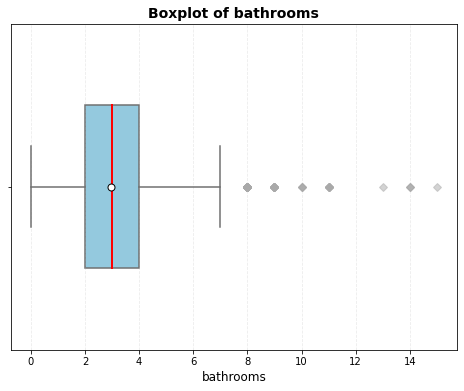

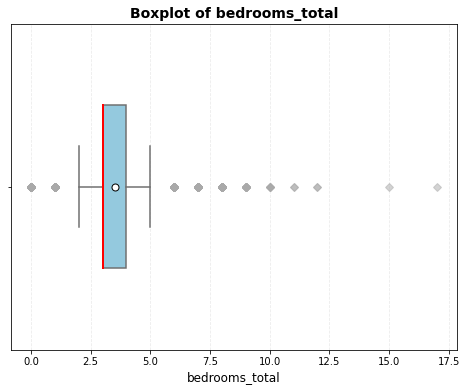

In [32]:
# Boxplot for selected numeric variables to review outliers
selected_numeric_cols = ["bathrooms", "bedrooms_total"]
for col in selected_numeric_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(
        data=df, 
        x=col, 
        showmeans=True,
        linewidth=1.5,
        color="skyblue",
        width=0.5,
        medianprops={"color": "red", "linewidth": 2},
        meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 7
    },
    flierprops={
        "marker": "D",
        "markerfacecolor": "darkgray",
        "markeredgecolor": "darkgray",
        "markersize": 5,
        "alpha": 0.5
    }
    )
    plt.title(f"Boxplot of {col}", fontsize=14, fontweight='bold')
    plt.xlabel(col, fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.25)
    plt.show()

The boxplots for bathrooms and bedrooms_total show that most properties are concentrated within a relatively narrow range. Bathrooms are mostly between 2 and 4, while total bedrooms are mostly between 3 and 4. Both variables have several high-end values beyond the upper whisker, which may represent potential outliers. These values should be reviewed further using the IQR method before deciding whether to keep, cap, or remove them.

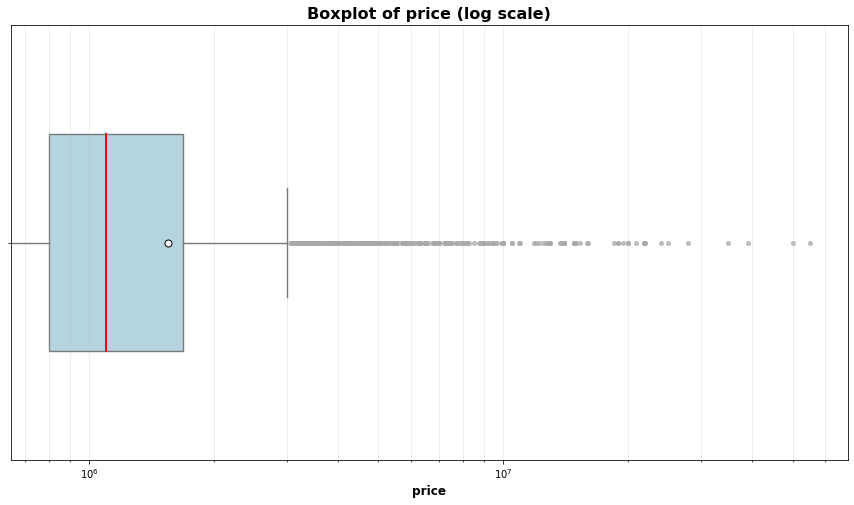

In [33]:
# Log-scale boxplot for price
plt.figure(figsize=(15, 8))
sns.boxplot(
    data=df,
    x="price",
    color="lightblue",
    width=0.5,
    linewidth=1.4,
    showmeans=True,
    medianprops={"color": "red", "linewidth": 2},
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 7
    },
    flierprops={
        "marker": "o",
        "markerfacecolor": "darkgray",
        "markeredgecolor": "darkgray",
        "markersize": 4,
        "alpha": 0.7
    }
)
plt.xscale("log")
plt.title("Boxplot of price (log scale)", fontsize=16, fontweight="bold")
plt.xlabel("price",fontsize=12, fontweight="bold")
plt.grid(axis="x", which = 'both', alpha=0.25)
plt.show()

The price boxplot shows a strongly right-skewed distribution, with most properties concentrated at lower price ranges and several high-priced properties appearing as potential outliers. The left whisker is less visible because the lower-price values are tightly clustered compared with the long right tail.

In [34]:
# Calculate IQR bounds for selected numeric variables
iqr_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    
    iqr_summary.append({
        "variable": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outlier_count
    })

iqr_summary_df = pd.DataFrame(iqr_summary)
iqr_summary_df

,variable,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count
0,price,799000.0,1688000.0,889000.0,-534500.0,3021500.0,541
1,bathrooms,2.0,4.0,2.0,-1.0,7.0,62
2,bedrooms_total,3.0,4.0,1.0,1.5,5.5,1247


The IQR method flagged potential outliers mainly on the upper end of the distributions. Negative lower bounds for price and bathrooms are not meaningful in a real estate context, so the upper bounds are more relevant for review. For bedrooms_total, very low values may represent small units or studios, while high bedroom and bathroom counts may represent large or luxury properties. These records should be reviewed further rather than removed automatically.

### 7.1 Review of Extreme Observations

Potential outliers identified by the IQR method are reviewed to determine whether they represent data quality issues or legitimate high-value properties.

In [35]:
df.sort_values(by="price", ascending=False).head(10).head(10)

,price,region,address,bedrooms,bathrooms,bedrooms_main,bedrooms_additional,bedrooms_total,bathrooms_missing,bedrooms_missing
5185,55000000.0,"Vaughan, ON","11874 KEELE ST, Vaughan, Ontario",NaN,3.0,NaN,0.0,3.0,1,1
2641,50000000.0,"Caledon, ON","13960 BRAMALEA RD, Caledon, Ontario",NaN,3.0,NaN,0.0,3.0,1,1
6431,39000000.0,"Hamilton, ON","721 MUD ST E, Hamilton, Ontario",NaN,3.0,NaN,0.0,3.0,1,1
2668,34999999.0,"Caledon, ON","12125 COLERAINE DR, Caledon, Ontario",NaN,3.0,NaN,0.0,3.0,1,1
5228,27975000.0,"Vaughan, ON","11065 PINE VALLEY DR, Vaughan, Ontario",5 + 2,6.0,5.0,2.0,7.0,0,0
3525,25000000.0,"East Gwillimbury, ON","18444 YONGE ST, East Gwillimbury, Ontario",NaN,3.0,NaN,0.0,3.0,1,1
4224,23999000.0,"Markham, ON","4201* HIGHWAY 7, Markham, Ontario",NaN,3.0,NaN,0.0,3.0,1,1
1481,21990000.0,"Milton, ON","8283 ESQUESING LINE, Milton, Ontario",NaN,3.0,NaN,0.0,3.0,1,1
1480,21990000.0,"Milton, ON","8283 ESQUESING LINE, Milton, Ontario",3,1.0,3.0,0.0,3.0,0,0
6679,21900000.0,"Guelph, ON","41-44 GEORGE Street, Guelph, Ontario",NaN,3.0,NaN,0.0,3.0,1,1


Among the ten highest-priced properties, most records had missing bedroom information in the original dataset. As a result, their bedrooms_total values were generated through median imputation and should not be interpreted as actual bedroom counts. Therefore, no meaningful conclusions can be drawn about the relationship between price and bedroom count for these records.

In [36]:
df.sort_values(by="bedrooms_total", ascending=False).head(10)

,price,region,address,bedrooms,bathrooms,bedrooms_main,bedrooms_additional,bedrooms_total,bathrooms_missing,bedrooms_missing
5421,12880000.0,"Whitchurch-Stouffville, ON","13231 KENNEDY RD, Whitchurch-Stouffville, Ontario",9 + 8,14.0,9.0,8.0,17.0,0,0
6975,999000.0,"Kitchener, ON","1097 QUEENS BLVD, Kitchener, Ontario",8 + 7,5.0,8.0,7.0,15.0,0,0
1142,2249000.0,"Burlington, ON","664-670 FRANCIS RD, Burlington, Ontario",9 + 3,4.0,9.0,3.0,12.0,0,0
2642,2299000.0,"Caledon, ON","15685 INNIS LAKE RD, Caledon, Ontario",7 + 5,6.0,7.0,5.0,12.0,0,0
2584,6500000.0,"Caledon, ON","13358 MCLAUGHLIN RD, Caledon, Ontario",7 + 4,11.0,7.0,4.0,11.0,0,0
5659,2499900.0,"Old Toronto, Toronto, ON","78 GLADSTONE AVE, Toronto, Ontario",9 + 2,7.0,9.0,2.0,11.0,0,0
7624,2899000.0,"Scarborough, Toronto, ON","52 ALLISTER AVE, Toronto, Ontario",5 + 5,5.0,5.0,5.0,10.0,0,0
7749,1820000.0,"Scarborough, Toronto, ON","103 SLAN AVE, Toronto, Ontario",7 + 3,4.0,7.0,3.0,10.0,0,0
3712,7498000.0,"King, ON","16252 CONCESSION 11, King, Ontario",8 + 2,9.0,8.0,2.0,10.0,0,0
5279,4199900.0,"Vaughan, ON","11900 KEELE ST, Vaughan, Ontario",6 + 4,6.0,6.0,4.0,10.0,0,0


The largest bedroom counts appear to be legitimate observations rather than data quality issues. Many properties include both main and additional bedrooms (e.g., 9 + 8 or 8 + 7), resulting in high total bedroom counts. These records likely represent large residential or multi-unit properties and will be retained for further analysis.

In [37]:
df.sort_values(by="bathrooms", ascending=False).head(10)

,price,region,address,bedrooms,bathrooms,bedrooms_main,bedrooms_additional,bedrooms_total,bathrooms_missing,bedrooms_missing
1930,1399000.0,"Brampton, ON","396 ROYAL WEST DR, Brampton, Ontario",3 + 1,15.0,3.0,1.0,4.0,0,0
5731,2799000.0,"Old Toronto, Toronto, ON","77 WILSON PARK RD, Toronto, Ontario",7 + 2,14.0,7.0,2.0,9.0,0,0
5421,12880000.0,"Whitchurch-Stouffville, ON","13231 KENNEDY RD, Whitchurch-Stouffville, Ontario",9 + 8,14.0,9.0,8.0,17.0,0,0
3705,20000000.0,"King, ON","14900 7TH CONCESSION RD, King, Ontario",8,14.0,8.0,0.0,8.0,0,0
2635,6799000.0,"Caledon, ON","9 FLAHERTY Lane, Caledon, Ontario",6 + 1,13.0,6.0,1.0,7.0,0,0
2584,6500000.0,"Caledon, ON","13358 MCLAUGHLIN RD, Caledon, Ontario",7 + 4,11.0,7.0,4.0,11.0,0,0
2634,6799000.0,"Caledon, ON","9 FLAHERTY LANE, Caledon, Ontario",6 + 1,11.0,6.0,1.0,7.0,0,0
5215,10500000.0,"Vaughan, ON","#UPH801 -1 CORDOBA DR, Vaughan, Ontario",5,11.0,5.0,0.0,5.0,0,0
2997,4488888.0,"Mississauga, ON","2419 CAMILLA RD, Mississauga, Ontario",6 + 3,11.0,6.0,3.0,9.0,0,0
5420,9950000.0,"Whitchurch-Stouffville, ON","16496 NINTH LINE, Whitchurch-Stouffville, Ontario",6,11.0,6.0,0.0,6.0,0,0


Several properties show unusually high bathroom counts relative to their reported bedroom counts. While some observations may represent large or specialized properties, others appear less intuitive and warrant further review. However, there is insufficient evidence to classify these records as data entry errors, so they will be retained at this stage.

### 7.2 Outlier Handling Decision

Potential outliers were identified using the IQR method and reviewed using summary statistics, visualizations, and record-level inspection. Although several observations appear unusual, they may represent legitimate luxury, large, or multi-unit properties rather than data quality errors. Therefore, no outliers were removed at this stage, and all records will be retained for further analysis and modeling.

## 8. EDA and Feature Engineering

This section explores the cleaned dataset to identify key patterns, relationships, and market trends. Additional features are created where appropriate to support business insights and predictive modeling.

### 8.1 Price Distribution

Understanding the distribution of property prices is important for identifying market characteristics, assessing skewness, and determining whether transformations may be beneficial for regression modeling.

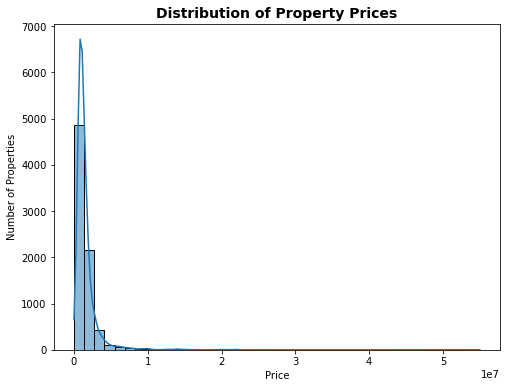

In [38]:
plt.figure(figsize=(8, 6))

sns.histplot(
    data=df,
    x="price",
    bins=40,
    kde=True
)

plt.title(
    "Distribution of Property Prices",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Price")
plt.ylabel("Number of Properties")

plt.show()

The distribution is highly right-skewed, making it difficult to interpret the main concentration of properties using the raw price scale.

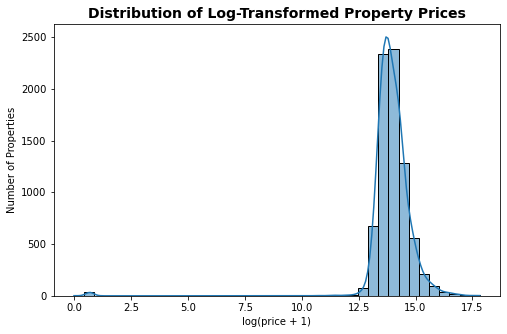

In [39]:
# log-transform price to better visualize distribution
plt.figure(figsize=(8, 5))

sns.histplot(
    np.log1p(df["price"]), #log1p means log(price + 1), to handle zero values if any
    bins=40,
    kde=True
)

plt.title(
    "Distribution of Log-Transformed Property Prices",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("log(price + 1)")
plt.ylabel("Number of Properties")

plt.show()

The log-transformed price distribution is substantially less skewed than the original price distribution, making the underlying structure of the market easier to interpret. Most properties appear to be concentrated within a relatively narrow range after transformation, while the influence of extremely high-priced properties is reduced. This suggests that a logarithmic transformation may be beneficial for regression modeling.

In [40]:
# Reviewing Zero-priced Properties
(df["price"]==0).sum()

1

In [41]:
df.loc[df["price"]==0, ["price","address", "region", "bedrooms_total", "bathrooms"]]

,price,address,region,bedrooms_total,bathrooms
1903,0.0,"N/A UPPER MIDDLE RD E, Oakville, Ontario","Oakville, ON",3.0,3.0


The dataset contains a single property with a recorded price of 0. Given that the property has valid bedroom and bathroom information, this value is likely the result of a missing or incorrectly recorded listing price rather than a legitimate market value. The record will be reviewed again before regression modeling.

### 8.2 Bedroom Distribution

Understanding the distribution of total bedrooms helps identify the typical property size in the dataset and highlights the presence of unusually small or large properties.

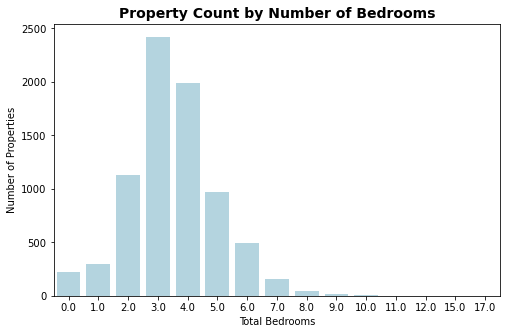

In [42]:
bedroom_counts = (
    df["bedrooms_total"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=bedroom_counts.index,
    y=bedroom_counts.values,
    color="lightblue"
)

plt.title(
    "Property Count by Number of Bedrooms",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Total Bedrooms")
plt.ylabel("Number of Properties")

plt.show()

Most properties in the dataset have between three and five bedrooms, with three-bedroom homes being the most common. The number of properties decreases as the bedroom count increases, while a small number of large properties with high bedroom counts are also present.

### 8.3 Bathroom Distribution

Understanding the distribution of bathrooms helps identify typical property characteristics and highlights the presence of unusually large properties within the dataset.

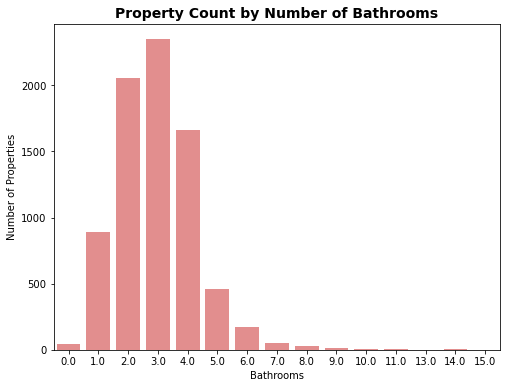

In [43]:

bathroom_counts = (
    df["bathrooms"]
    .value_counts()
    .sort_index()
)
plt.figure(figsize=(8,6))
sns.barplot(
    x=bathroom_counts.index,
    y=bathroom_counts.values,
    color="lightcoral"  
)
plt.title(
    "Property Count by Number of Bathrooms",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Bathrooms")
plt.ylabel("Number of Properties")
plt.show()


Most properties contain between two and four bathrooms, with three-bathroom properties representing the largest segment of the dataset. The frequency decreases as the number of bathrooms increases, indicating that properties with a large number of bathrooms are relatively uncommon. A small number of high-bathroom-count properties remain present and may represent larger or luxury homes.

### 8.4 Property Characteristics and Price Relationships

This section explores how key property characteristics relate to property prices. Understanding these relationships helps identify the factors most strongly associated with higher-priced properties and provides valuable insights for both business analysis and predictive modeling.

#### 8.4.1 Median Property Price by Number of Bedrooms

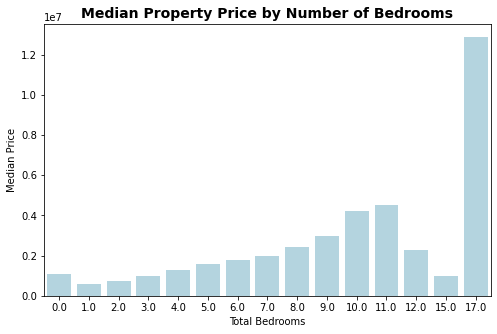

In [44]:
bedroom_price = (
    df.groupby("bedrooms_total")["price"]
      .median()
      .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=bedroom_price,
    x="bedrooms_total",
    y="price",
    color="lightblue"
)

plt.title(
    "Median Property Price by Number of Bedrooms",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Total Bedrooms")
plt.ylabel("Median Price")

plt.show()

The initial chart suggested that properties with a large number of bedrooms tend to have higher median prices.

However, before drawing conclusions, it is important to examine how many properties belong to each bedroom category.

Categories with only a few observations may not accurately represent the market. Therefore, bedroom frequencies are reviewed before refining the analysis.

In [45]:
# Review bedroom category frequencies
df["bedrooms_total"].value_counts().sort_index()

0.0      223
1.0      300
2.0     1130
3.0     2421
4.0     1986
5.0      967
6.0      497
7.0      153
8.0       49
9.0       14
10.0       5
11.0       2
12.0       2
15.0       1
17.0       1
Name: bedrooms_total, dtype: int64

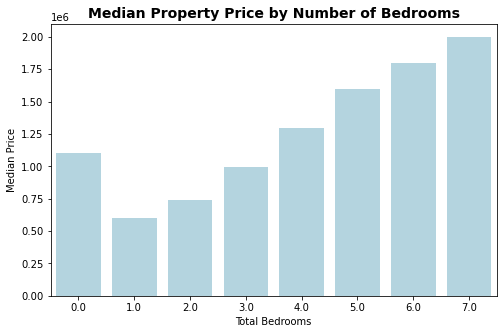

In [46]:
# Focus on bedroom categories with sufficient observations
df_bed = df[df["bedrooms_total"] <= 7]

bedroom_price_refined = (
    df_bed.groupby("bedrooms_total")["price"]
    .median()
    .reset_index()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=bedroom_price_refined,
    x="bedrooms_total",
    y="price",
    color="lightblue"
)

plt.title(
    "Median Property Price by Number of Bedrooms",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Total Bedrooms")
plt.ylabel("Median Price")

plt.show()


After removing bedroom categories with very few observations, a clearer relationship between bedroom count and property price emerges.

Median property prices generally increase as the number of bedrooms increases, indicating that larger properties tend to command higher market values. The strongest concentration of properties is observed between 2 and 5 bedrooms, which represents the core segment of the market.

### 8.4.2 Median Property Price by Number of Bathrooms

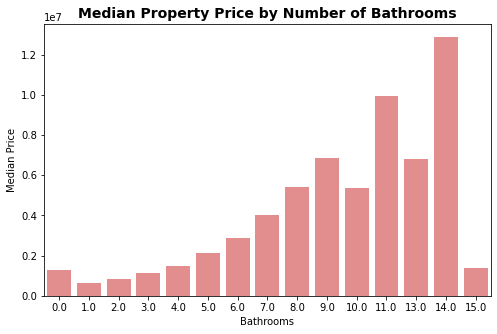

In [47]:
bathroom_price = (
    df.groupby("bathrooms")["price"]
    .median()
    .reset_index()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=bathroom_price,
    x="bathrooms",
    y="price",
    color="lightcoral"
)

plt.title(
    "Median Property Price by Number of Bathrooms",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Bathrooms")
plt.ylabel("Median Price")

plt.show()

The initial chart suggested that properties with a larger number of bathrooms tend to have higher median prices.

However, before drawing conclusions, it is important to examine how many properties belong to each bathroom category.

Categories with only a few observations may not accurately represent the market. Therefore, bathroom frequencies are reviewed before refining the analysis.

In [48]:
# Review bathroom category frequencies
df["bathrooms"].value_counts().sort_index()

0.0       43
1.0      892
2.0     2053
3.0     2349
4.0     1664
5.0      460
6.0      175
7.0       53
8.0       29
9.0       15
10.0       4
11.0       9
13.0       1
14.0       3
15.0       1
Name: bathrooms, dtype: int64

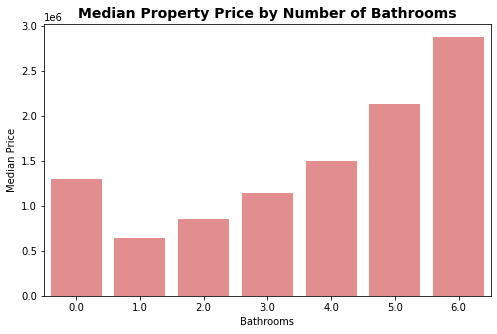

In [49]:
# Focus on bathroom categories with sufficient observations
df_bath = df[df["bathrooms"] <= 6]

bathroom_price_refined = (
    df_bath.groupby("bathrooms")["price"]
    .median()
    .reset_index()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=bathroom_price_refined,
    x="bathrooms",
    y="price",
    color="lightcoral"
)

plt.title(
    "Median Property Price by Number of Bathrooms",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Bathrooms")
plt.ylabel("Median Price")
plt.show()

After excluding bathroom categories with very few observations, a clearer relationship between bathroom count and property price becomes visible.

Median property prices generally increase as the number of bathrooms increases, suggesting that larger and more highly equipped properties tend to command higher market values. Most properties in the dataset contain between 2 and 4 bathrooms, representing the core segment of the market.

## 8.5 Correlation Analysis

Correlation analysis helps identify the strength and direction of relationships between numerical variables in the dataset. This provides an initial understanding of which property characteristics may be most useful for predictive modeling.

In [50]:
numeric_cols = ["price","bedrooms_total","bathrooms"]

corr_matrix = df[numeric_cols].corr()

corr_matrix

,price,bedrooms_total,bathrooms
price,1.000000,0.222020,0.374306
bedrooms_total,0.222020,1.000000,0.654472
bathrooms,0.374306,0.654472,1.000000


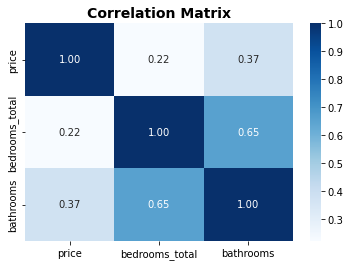

In [51]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title(
    "Correlation Matrix",
    fontsize=14,
    fontweight="bold"
)

plt.show()

### Key Findings:

- Bathrooms show a stronger correlation with price than bedrooms.
- Both correlations are positive, indicating that larger properties tend to have higher listing prices.
- The correlations are relatively moderate, suggesting that additional factors beyond bedroom and bathroom counts also influence property prices.
- Bedrooms and bathrooms are moderately correlated with each other, which is expected as larger homes typically contain more of both features.

## 9. Feature Engineering

Before building regression models, relevant features are prepared and transformed to improve model performance. Feature engineering helps represent property characteristics more effectively while preserving business interpretability.

In [52]:
df.columns

Index(['price', 'region', 'address', 'bedrooms', 'bathrooms', 'bedrooms_main',
       'bedrooms_additional', 'bedrooms_total', 'bathrooms_missing',
       'bedrooms_missing'],
      dtype='object')

In [53]:
# Check how many unique regions exist in the dataset
df['region'].nunique()

31

In [54]:
# Evaluate regional price differences before transforming the region feature
region_price = (
    df.groupby('region')['price']
      .agg(['count', 'median'])
      .sort_values('median', ascending=False)
)

region_price

,count,median
region,,
"King, ON",70,2899000.0
"Caledon, ON",155,1988000.0
"Oakville, ON",440,1799450.0
"Aurora, ON",147,1798000.0
"East Gwillimbury, ON",111,1700000.0
"Richmond Hill, ON",401,1698000.0
"Whitchurch-Stouffville, ON",129,1499000.0
"Halton Hills, ON",92,1399900.0
"Markham, ON",493,1399900.0


Regional median prices vary considerably across the dataset, suggesting that location is an important factor influencing property values. This supports the inclusion of region as a predictive feature in subsequent modeling.

In [55]:
# One-hot encode the region feature

df_encoded = pd.get_dummies(
    df,
    columns=['region'],
    drop_first=True
)

## 10. Regression Modeling

With the data preparation and feature engineering steps complete, we can now build a regression model to predict property prices. The model will be evaluated using standard regression metrics to assess its performance.

In [56]:
# Define features (x) and target (y)

columns=['price','address','bedrooms_main','bedrooms_additional','bedrooms','bedrooms_missing','bathrooms_missing']

X = df_encoded.drop(columns=columns)
y = df_encoded['price']


In [57]:
# Split data into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_test.shape

((6200, 32), (1551, 32))

In [58]:
# Train a Linear Regression model

from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [59]:
# Generate predictions

y_pred = lr.predict(X_test)

In [60]:
# Evaluate model performance

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:,.0f}")
print(f"RMSE: {rmse:,.0f}")
print(f"R²: {r2:.3f}")


MAE: 658,430
RMSE: 1,758,747
R²: 0.186


### Model Performance Interpretation

The baseline Linear Regression model achieved an R² score of 0.186, indicating that approximately 18.6% of the variation in property prices is explained by the selected features.

The relatively high MAE and RMSE values suggest that prediction errors remain substantial. This is likely due to the limited number of available predictors, as property prices are influenced by many additional factors such as property size, building age, property type, and other location-specific characteristics that are not included in the dataset.

Overall, the model provides a useful baseline for understanding the relationship between property characteristics and price, but additional features would be required to improve predictive performance.

## 9. Residual Analysis

Residuals represent the difference between actual and predicted property prices.

The residual plot was used to evaluate the distribution of prediction errors and identify any patterns that may indicate limitations in the baseline Linear Regression model.

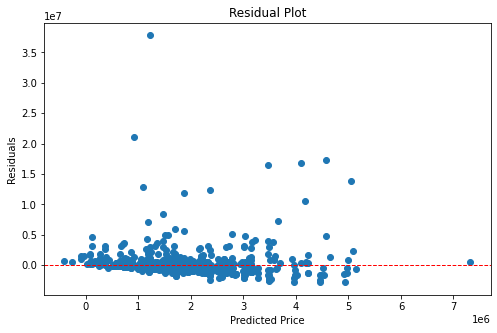

In [61]:
# Calculate residuals
residuals = y_test - y_pred

# Create residual plot
plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle="--", color="red", linewidth=1)

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

The residual plot shows that most prediction errors are concentrated around zero, although several large residuals are present.

This observation is consistent with the model evaluation results, where RMSE is substantially higher than MAE, indicating the presence of some large prediction errors.

Overall, the residual analysis suggests that the model captures some pricing patterns but does not fully explain property price variation, likely due to the limited set of available features.

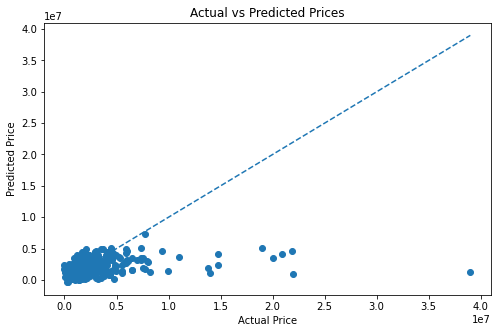

In [62]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

plt.show()

The Actual vs Predicted plot shows that predicted prices do not consistently align with actual property prices, particularly for higher-priced properties.

This result is consistent with the model's R² score and suggests that additional property-level features would be required to improve predictive performance.

## 10. Business Interpretation

### 10.1 Conclusion

This project analyzed Toronto residential property listings to identify factors associated with property prices.

The results showed that bedrooms, bathrooms, and region are all related to property values, with location appearing to be an important factor.

While the Linear Regression model captured some pricing patterns, additional property features would likely be needed to improve prediction accuracy.

Overall, the analysis provided useful market insights and demonstrated a complete data analytics workflow.

### 10.2 Business Questions

#### 1. Which regions have higher and lower property prices?

The regional analysis showed noticeable differences in property prices across the GTA. Some regions consistently had higher median prices than others, suggesting that location plays an important role in determining property value.

#### 2. How are bedrooms and bathrooms related to property prices?

The analysis showed a positive relationship between both bedrooms and bathrooms and property prices. In general, properties with more bedrooms and bathrooms tended to have higher median prices.

#### 3. What factors appear to have the strongest relationship with property value?

Based on the exploratory analysis, region appears to be one of the most important factors associated with property prices. Bedrooms and bathrooms also contribute to price differences, but location seems to have a stronger influence on property value.

#### 4. Can property prices be estimated using a Linear Regression model?

The Linear Regression model was able to capture some general pricing patterns using the available features. However, the model achieved an R² score of approximately 0.186, indicating that the selected variables explain only a portion of the variation in property prices.

#### 5. What are the main limitations of the available data for property price prediction?

One of the main limitations of the dataset is the lack of important property characteristics such as square footage, property type, building age, lot size, and other neighborhood-level factors. These missing variables likely affect property prices and limit the model’s predictive performance.

### 10.3 Recommendations

Based on the analysis, several opportunities exist to improve future property price modeling efforts.

* Collect additional property characteristics such as square footage, property type, building age, lot size, and parking information.
* Use more detailed neighborhood-level information, since the analysis showed that location is strongly associated with property prices.
* Treat the current Linear Regression model as a baseline model for future comparison.
* Evaluate additional machine learning models after improving the available features.
* Focus on improving data quality and feature coverage, as the current results suggest that important drivers of property prices are not captured in the dataset.

Overall, the analysis showed that bedrooms, bathrooms, and region provide useful information about property values, but additional property-level features would likely be needed to achieve stronger predictive performance.